# Team F1's Linear Regression model

Team members include Patrick Martin II, Carter Swift, Jaegeon Shin and Merlin Hart

In [ ]:
#importing all the different libraries that we will need for this part. 
#using the erdos_summer_2025 environment

#normal libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

#Sklean libraries and functions
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score


Here we pull in the data that will to be used for our predictors and qualifiers.  We can pull from two different csv files, but should be careful that they line up. <br>
The list in the X dataframe should contain all the different columns that we want to use, such as "gap_between_mean" or "circuitType_RACE"

In [ ]:
#Loading in the cleaned training data
xdata = pd.read_csv("gaps and circuit type (cleaned).csv")
ydata = pd.read_csv("Average Local Positions.csv")
xdata2 = pd.read_csv("paceRankStartPositionDeltas_withDNF.csv")  #can us the file without "_withDNF" 

# Combining all the different csv files into one usable dataframe.

xdata = pd.merge(xdata,xdata2, on = "raceId", how = 'inner')


#Creating our training and test dataframes
X  = xdata[ ["Bgap_median","absGridDelta","circuitType_STREET"]]

Y = ydata[ "average_local_position"]  #this is our target, what we are trying to predict, and will use this to test our predictive model. 


X_train,X_test , Y_train, Y_test = train_test_split(X,Y , test_size= 0.2, shuffle=True, random_state= 117)


Here we create the pipeline for how our model will be run.  We are using the Linear Regression model, and we are normalizing our predictor values via StandaScalar.

In [3]:
#create cross-validation sets for model selection
kfold = KFold(n_splits = 4, shuffle=True, random_state=42)

#creating the pipleline for our Model. 

modelPipeline = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('poly', PolynomialFeatures(degree = 2, 
                                  interaction_only= True,
                                  include_bias= False) 
                                  ),
    ('reg' , LinearRegression())  # this is the model that we are using, which can be anything we want. 
])



Here is where we train the model, making sure not to use any of our testing data.  That would mean there is data leakage. 

In [8]:

modelPipeline.fit(X_train,Y_train)  #here we are fitting our model with the testing data




Pipeline(steps=[('scalar', StandardScaler()),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('reg', LinearRegression())])

### Model Selection: Look at performance on cross-validation sets

In [9]:
rmses = np.zeros(4)
r2_scores = np.zeros(4)


for i, (train_index, test_index) in enumerate(kfold.split(X_train, Y_train)):
    X_train_train = X_train.iloc[train_index,:]
    Y_train_train = Y_train.iloc[train_index]

    X_holdout = X_train.iloc[test_index,:]
    Y_holdout = Y_train.iloc[test_index]

    modelPipeline.fit(X_train_train,Y_train_train)

    y_pred = modelPipeline.predict(X_holdout)

    rmses[i] = root_mean_squared_error(y_pred, Y_holdout)
    r2_scores[i] = r2_score(Y_holdout,y_pred)

print(rmses, rmses.mean())
print(r2_scores, r2_scores.mean())

[0.80929925 0.93198391 0.86946695 0.86900109] 0.8699377994720361
[0.16610522 0.10378438 0.19329344 0.11999562] 0.14579466532681049


## Final Step: Predict on test set (only after final model is chosen)

Now we can use our trained model to make predictions from the testing predictors, and compare them to the actual predictors from the testing set. 

In [10]:
modelPipeline.fit(X_train,Y_train)

Y_pred = modelPipeline.predict(X_test) 

rmse = root_mean_squared_error(Y_pred, Y_test)
r2 = r2_score(Y_test,Y_pred)

print(np.std(Y_test))


print(f"Root Mean squared error: {rmse}")
print(f"R^2 value : {r2}")

0.9236025076447286
Root Mean squared error: 0.8600561565237254
R^2 value : 0.13287159828932427


In [11]:
final = X_test
final["actual"] = Y_test
final["predicted"] = Y_pred
final["delta"] = Y_test - Y_pred

In [12]:
final

,Bgap_median,absGridDelta,circuitType_STREET,actual,predicted,delta
640,135.0,2.700000,False,3.411765,2.642664,0.769101
613,62.0,1.000000,False,3.375000,2.359998,1.015002
471,85.5,1.272727,False,3.263158,2.376926,0.886232
100,158.5,1.230769,False,2.307692,2.268101,0.039591
244,192.0,1.636364,False,1.692308,2.333738,-0.641430
...,...,...,...,...,...,...
218,75.5,0.818182,False,3.000000,2.304828,0.695172
246,206.5,0.000000,False,1.272727,1.849273,-0.576546
478,338.0,2.380952,False,1.714286,2.463781,-0.749495
437,182.5,0.333333,False,2.315789,1.994029,0.321761


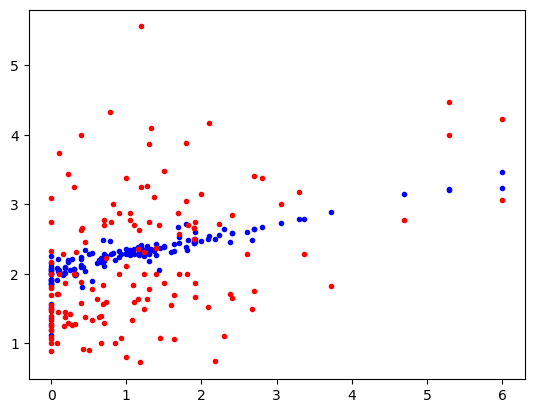

In [13]:
plt.plot(final["absGridDelta"],final["predicted"],'b.')
plt.plot(final["absGridDelta"],final["actual"],'r.')

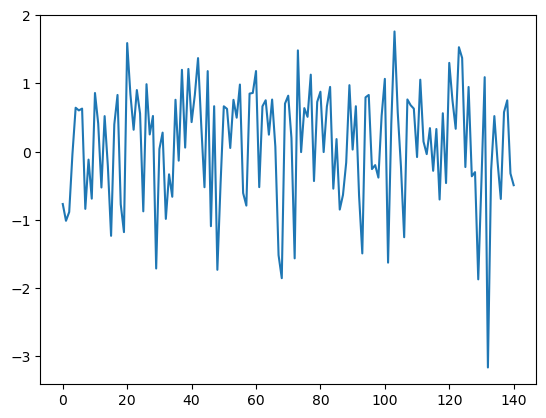

In [15]:
plt.plot((Y_pred- Y_test.to_list()))


In [16]:
print(modelPipeline.named_steps['reg'].coef_)

[-0.20010154  0.31386708 -0.01573457  0.096087   -0.11093515  0.01865018]


In [17]:
#Visualize using full data
full = X.copy()

modelPipeline.fit(X,Y)

full["actual"] = Y
full["pred"] = modelPipeline.predict(X)
full["error"] = full["pred"] - full["actual"]
full["index"] = list(range(len(full)))

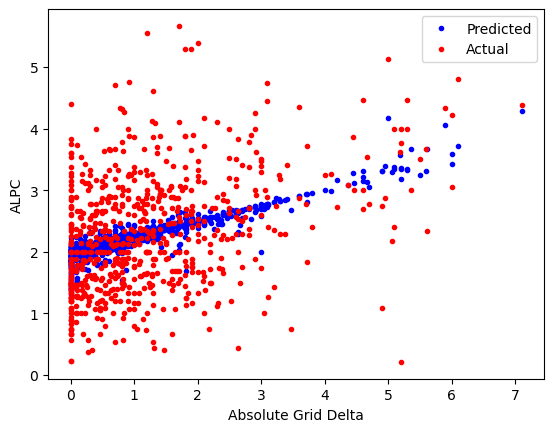

In [18]:
plt.plot(full["absGridDelta"],full["pred"],'b.')
plt.plot(full["absGridDelta"],full["actual"],'r.')
plt.xlabel("Absolute Grid Delta")
plt.ylabel("ALPC")
plt.legend(["Predicted","Actual"])

<Axes: xlabel='absGridDelta', ylabel='pred'>

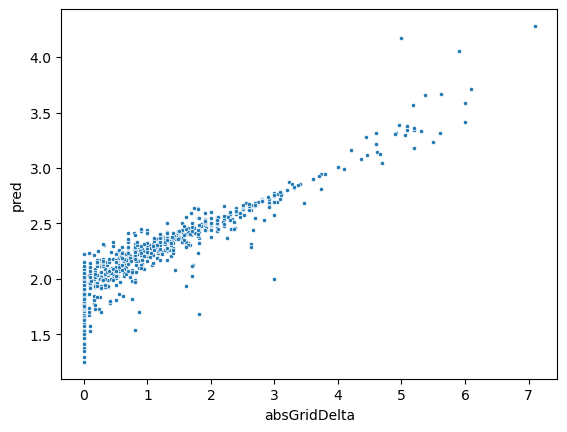

In [19]:
sns.scatterplot(data=full,x="absGridDelta",y="pred",marker=".")

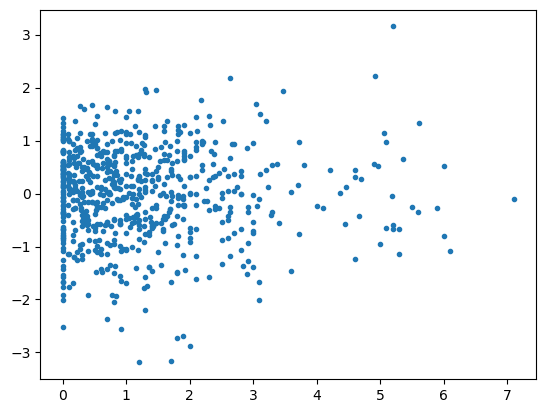

In [20]:
plt.plot(full["absGridDelta"],full["error"],'.')